In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Clustering\data\Cust_Segmentation.csv")
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,850.000000
mean,425.50000,35.029412,1.710588,8.565882,46.675294,1.576820,3.078773,0.261429,10.171647
std,245.51816,8.041432,0.927784,6.777884,38.543054,2.125843,3.398799,0.439727,6.719441
min,1.00000,20.000000,1.000000,0.000000,13.000000,0.012000,0.046000,0.000000,0.100000
25%,213.25000,29.000000,1.000000,3.000000,24.000000,0.382500,1.045750,0.000000,5.100000
50%,425.50000,34.000000,1.000000,7.000000,35.000000,0.885000,2.003000,0.000000,8.700000
75%,637.75000,41.000000,2.000000,13.000000,55.750000,1.898500,3.903250,1.000000,13.800000
max,850.00000,56.000000,5.000000,33.000000,446.000000,20.561000,35.197000,1.000000,41.300000


In [3]:
#Drop irrelevant columns
df=df.drop(['Customer Id','Address','Defaulted'],axis=1)

In [4]:
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,6.3
1,47,1,26,100,4.582,8.218,12.8
2,33,2,10,57,6.111,5.802,20.9
3,29,2,4,19,0.681,0.516,6.3
4,47,1,31,253,9.308,8.908,7.2


In [5]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(df)

In [6]:
#Apply K-means
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X)
labels=kmeans.labels_
df['Cluster']=labels
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,Cluster
0,41,2,6,19,0.124,1.073,6.3,1
1,47,1,26,100,4.582,8.218,12.8,2
2,33,2,10,57,6.111,5.802,20.9,2
3,29,2,4,19,0.681,0.516,6.3,1
4,47,1,31,253,9.308,8.908,7.2,2


In [7]:
#Check Cluster centers
kmeans.cluster_centers_

array([[ 0.80071761, -0.16592358,  0.65301855,  0.24796374, -0.1314766 ,
        -0.10255272, -0.3264944 ],
       [-0.64823488,  0.00663256, -0.62462116, -0.48431462, -0.31594156,
        -0.37324031, -0.04182489],
       [ 0.74779498,  0.42842821,  1.04825715,  1.52710627,  1.80691341,
         1.98872404,  1.09374332]])

<function matplotlib.pyplot.show(close=None, block=None)>

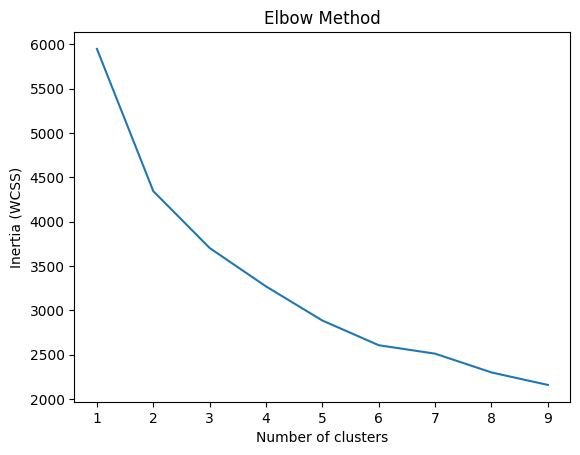

In [8]:
#Choose K
import matplotlib.pyplot as plt
inertia=[]
for k in range(1,10):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
plt.plot(range(1,10),inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show

In [10]:
#Silhouette Score
from sklearn.metrics import silhouette_score
for k in range(2,6):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X,labels)
    print(f"K={k},Silhouette Score= {score}")

K=2,Silhouette Score= 0.3752435082245413
K=3,Silhouette Score= 0.2172394086659741
K=4,Silhouette Score= 0.2453672982285242
K=5,Silhouette Score= 0.24980591694366872


In [11]:
kmeans=KMeans(n_clusters=2,random_state=42)
df['Cluster']=kmeans.fit_predict(X)
df['Cluster'].value_counts()

Cluster
1    667
0    183
Name: count, dtype: int64

In [12]:
df.groupby('Cluster').mean()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
Cluster,,,,,,,
0,42.579235,1.956284,16.103825,94.382514,3.912016,7.408268,14.020219
1,32.958021,1.643178,6.497751,33.586207,0.936129,1.890921,9.115742


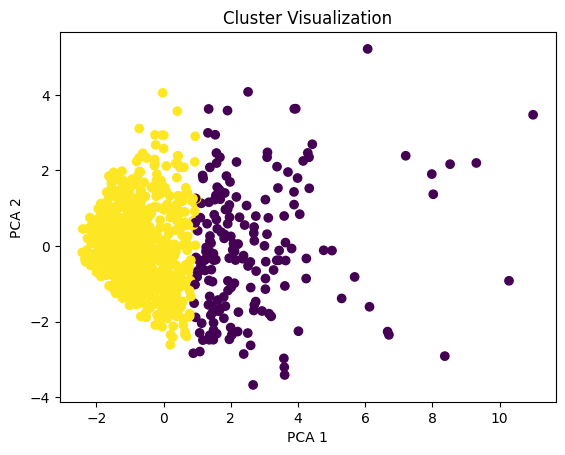

In [13]:
#Visualize with PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.scatter(X_pca[:,0],X_pca[:,1], c=df['Cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization")
plt.show()

PCA => Principal Component Analysis: Technique used to reduce the no. of features in dataset while keeping most of the imp. information.